In [1]:
import math
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---
# 1) Setup

## 1.1 Dataset: CIFAR-10

CIFAR-10 contains 60 000 colour images (32×32 pixels, 3 channels) across 10 mutually exclusive
classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

- **Train:** 50 000 images
- **Test:** 10 000 images

We will further carve a **validation set** (5 000 images) from the training split so we can
monitor generalisation during training *without* touching the test set.

In [2]:
# Download raw CIFAR-10 (no transforms yet — we need raw data for exploration)
raw_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True)
raw_test = torchvision.datasets.CIFAR10(root="./data", train=False, download=True)

CIFAR10_CLASSES = raw_train.classes
num_classes = len(CIFAR10_CLASSES)

print(f"Training samples : {len(raw_train)}")
print(f"Test samples     : {len(raw_test)}")
print(f"Classes ({num_classes}): {CIFAR10_CLASSES}")
print(f"Image shape      : {raw_train[0][0].size} (PIL)")

100%|██████████| 170M/170M [00:03<00:00, 48.9MB/s]


Training samples : 50000
Test samples     : 10000
Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image shape      : (32, 32) (PIL)


## 1.2 Data Exploration & Visualization

Before modelling, always visualise a random sample and check for class imbalance.
CIFAR-10 is balanced by construction, but the habit of checking is essential.

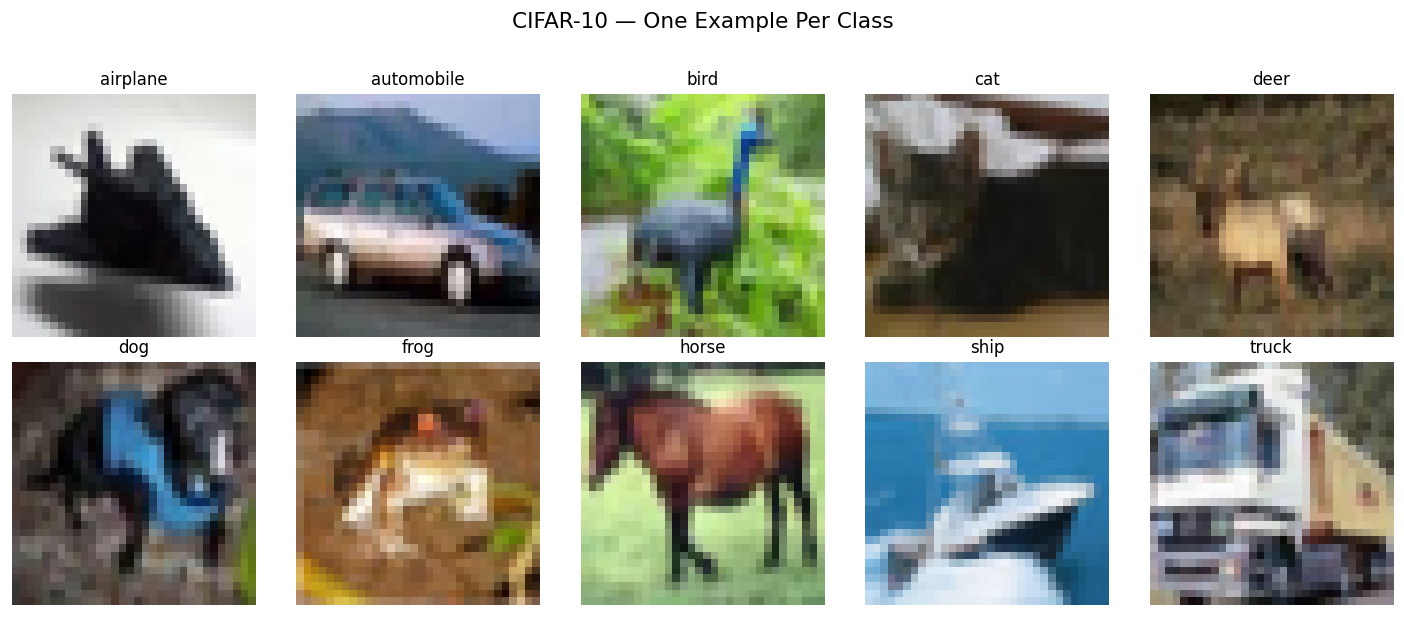

In [3]:
# Show a grid of example images — one per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
class_examples = {c: [] for c in range(num_classes)}

for img, label in raw_train:
    if len(class_examples[label]) < 1:
        class_examples[label].append(img)
    if all(len(v) >= 1 for v in class_examples.values()):
        break

for idx, ax in enumerate(axes.flat):
    ax.imshow(class_examples[idx][0])
    ax.set_title(CIFAR10_CLASSES[idx], fontsize=10)
    ax.axis("off")

fig.suptitle("CIFAR-10 — One Example Per Class", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

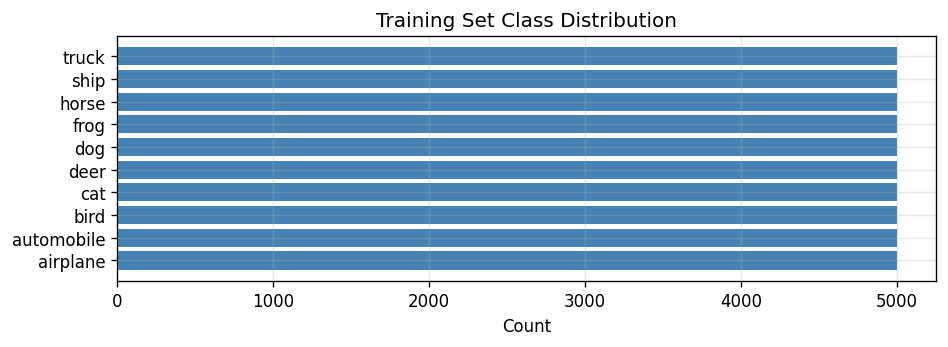

Min class count: 5000, Max class count: 5000 — balanced.


In [4]:
# Class distribution in training set
labels = np.array(raw_train.targets)
counts = np.bincount(labels, minlength=num_classes)

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(CIFAR10_CLASSES, counts, color="steelblue")
ax.set_xlabel("Count")
ax.set_title("Training Set Class Distribution")
plt.tight_layout()
plt.show()
print(f"Min class count: {counts.min()}, Max class count: {counts.max()} — balanced.")

## 1.3 Preprocessing: Normalization & Train/Val/Test Split

**Normalization**: We centre each channel to mean ≈ 0 and std ≈ 1 using the
*training set* statistics. This accelerates convergence by keeping activations in the
linear regime of common activations and aligns with the assumptions behind BatchNorm.

**Val split:** We hold out 10% of training data (5 000 images) as a validation set,
using a fixed random split for reproducibility.

In [5]:
# Compute channel-wise mean and std on training images
train_images = torch.tensor(raw_train.data, dtype=torch.float32) / 255.0
# (num_samples, height, width, channels) → per-channel stats
CIFAR10_MEAN = train_images.mean(dim=(0, 1, 2)).tolist()
CIFAR10_STD = train_images.std(dim=(0, 1, 2)).tolist()
print(f"Channel means: {[f'{m:.4f}' for m in CIFAR10_MEAN]}")
print(f"Channel stds:  {[f'{s:.4f}' for s in CIFAR10_STD]}")
del train_images

Channel means: ['0.4914', '0.4822', '0.4465']
Channel stds:  ['0.2470', '0.2435', '0.2616']


In [6]:
# Train/val split (stratified by class)
from torch.utils.data import random_split

VAL_SIZE = 5_000
TRAIN_SIZE = len(raw_train) - VAL_SIZE

generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices = random_split(
    range(len(raw_train)), [TRAIN_SIZE, VAL_SIZE], generator=generator
)
train_indices = list(train_indices)
val_indices = list(val_indices)
print(f"Train: {len(train_indices)}, Val: {len(val_indices)}")

Train: 45000, Val: 5000


## 1.4 Data Augmentation

Data augmentation is one of the most effective regularizers. By applying
*label-preserving* transformations at train time, we synthetically expand the effective
dataset size and reduce overfitting.

For CIFAR-10 the standard recipe is:
- **Random horizontal flip** (p=0.5): objects can appear mirrored.
- **Random crop with padding** (pad 4, crop back to 32×32): simulates slight translations.

We do **not** augment validation or test data — only deterministic normalisation.

In [7]:
# Training transforms: augmentation + normalization
transform_train = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(32, padding=4),
    T.ToTensor(),
    T.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

# Validation/test transforms: normalization only
transform_eval = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

## 1.5 DataLoader Setup

We wrap datasets into `DataLoader`s with:
- **Batch size 128** — fits comfortably in T4 GPU memory.
- **num_workers=2** — Colab has limited CPUs; 2 workers provide a good balance.
- **pin_memory=True** — speeds up host-to-device transfer.

In [8]:
# Create datasets with appropriate transforms
full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=False, transform=transform_train
)
full_eval_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=False, transform=transform_eval
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=False, transform=transform_eval
)

# Use Subset to get our train/val splits
train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_eval_dataset, val_indices)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True,
)

# Quick sanity check
x_batch, y_batch = next(iter(train_loader))
print(f"Batch shape : {x_batch.shape}")    # (batch_num, 3, 32, 32)
print(f"Labels shape: {y_batch.shape}")     # (batch_num,)
print(f"Pixel range  : [{x_batch.min():.2f}, {x_batch.max():.2f}] (normalised)")

Batch shape : torch.Size([128, 3, 32, 32])
Labels shape: torch.Size([128])
Pixel range  : [-1.99, 2.13] (normalised)


---
# 2) Architecture Design

Now we design the neural network itself. Every choice here is deliberate:

| Decision | Choice | Reference |
|---|---|---|
| Activation | ReLU | NB01 §2.3 — simple, avoids vanishing gradients |
| Normalization | BatchNorm | NB02 §2.1 — stabilises training, enables higher LR |
| Skip connections | Residual (additive) | NB02 §3.1 — combats degradation, helps gradient flow |
| Initialization | He (Kaiming) | NB01 §3.2 — matched to ReLU's variance profile |
| Pooling | Global Average Pool | Reduces parameters, acts as structural regularizer |


## Design Decisions

**Why residual blocks?** Deep plain networks suffer from the *degradation problem* (NB02 §3.1):
adding layers can actually *increase* training error. Residual connections fix this by providing
a gradient highway — the identity mapping lets gradients flow unimpeded through the network.

**Why BatchNorm before activation?** The original ResNet uses Conv → BN → ReLU ordering.
BatchNorm (NB02 §2.1) re-centres and re-scales pre-activations to prevent internal covariate
shift. Placing it *before* the activation ensures the activation receives well-conditioned inputs.

**Why He initialisation?** With ReLU activations, half the neurons are zeroed out. He init
(NB01 §3.2) compensates by scaling weights by √(2/fan_in), maintaining variance through
depth and preventing signal collapse or explosion at initialisation.

**Architecture blueprint:**
```
Input (3, 32, 32)
  → Conv 3×3 (3→64) → BN → ReLU
  → ResBlock(64→64) × 2                                    [32×32]
  → ResBlock(64→128, stride=2) + ResBlock(128→128)          [16×16]
  → ResBlock(128→256, stride=2) + ResBlock(256→256)         [8×8]
  → Global Average Pooling → (256,)
  → Linear(256→10)
```

Total: ~2.8M parameters — large enough to learn CIFAR-10 well, small enough for fast iteration.

## 2.1 Building Blocks: Conv → Norm → Activation → Residual

The fundamental unit is a **Residual Block** with two conv layers:
```
x → Conv → BN → ReLU → Conv → BN → (+x) → ReLU
```
When spatial dimensions change (stride > 1) or channels change, a 1×1 projection
shortcut aligns dimensions before the addition.

In [9]:
class ResBlock(nn.Module):
    """Residual block: two 3x3 convolutions with BatchNorm and skip connection."""

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()

        # (batch_num, in_channels, height, width) -> (batch_num, out_channels, height/stride, width/stride)
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3,
            stride=stride, padding=1, bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        # (batch_num, out_channels, h, w) -> (batch_num, out_channels, h, w)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3,
            stride=1, padding=1, bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut: identity if shapes match, else 1x1 projection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            # (batch_num, in_channels, height, width) -> (batch_num, out_channels, height/stride, width/stride)
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # (batch_num, in_channels, height, width) -> (batch_num, out_channels, h_out, w_out)
        identity = self.shortcut(x)

        # (batch_num, in_channels, height, width) -> (batch_num, out_channels, h_out, w_out)
        out = F.relu(self.bn1(self.conv1(x)))

        # (batch_num, out_channels, h_out, w_out) -> (batch_num, out_channels, h_out, w_out)
        out = self.bn2(self.conv2(out))

        # Residual addition (NB02 section 3.1): gradient flows through both paths
        # (batch_num, out_channels, h_out, w_out) + (batch_num, out_channels, h_out, w_out)
        out = out + identity
        out = F.relu(out)
        return out


# Quick test
block = ResBlock(64, 128, stride=2)
dummy = torch.randn(2, 64, 32, 32)
print(f"ResBlock(64->128, stride=2): {dummy.shape} -> {block(dummy).shape}")

ResBlock(64->128, stride=2): torch.Size([2, 64, 32, 32]) -> torch.Size([2, 128, 16, 16])


## 2.2 Custom CNN with Residual Blocks

In [10]:
class CIFAR10ResNet(nn.Module):
    """Custom ResNet for CIFAR-10 — built entirely from scratch."""

    def __init__(self, num_classes: int = 10):
        super().__init__()

        # Stem: initial feature extraction
        # (batch_num, 3, 32, 32) -> (batch_num, 64, 32, 32)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        # Residual stages
        # (batch_num, 64, 32, 32) -> (batch_num, 64, 32, 32)
        self.stage1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        # (batch_num, 64, 32, 32) -> (batch_num, 128, 16, 16)
        self.stage2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        # (batch_num, 128, 16, 16) -> (batch_num, 256, 8, 8)
        self.stage3 = self._make_layer(128, 256, num_blocks=2, stride=2)

        # Classification head
        # (batch_num, 256, 8, 8) -> (batch_num, 256, 1, 1) -> (batch_num, 256)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        # (batch_num, 256) -> (batch_num, num_classes)
        self.classifier = nn.Linear(256, num_classes)

    @staticmethod
    def _make_layer(
        in_channels: int, out_channels: int, num_blocks: int, stride: int
    ) -> nn.Sequential:
        layers = [ResBlock(in_channels, out_channels, stride=stride)]
        for _ in range(1, num_blocks):
            layers.append(ResBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # (batch_num, 3, 32, 32) -> (batch_num, 64, 32, 32)
        x = self.stem(x)
        # (batch_num, 64, 32, 32) -> (batch_num, 64, 32, 32)
        x = self.stage1(x)
        # (batch_num, 64, 32, 32) -> (batch_num, 128, 16, 16)
        x = self.stage2(x)
        # (batch_num, 128, 16, 16) -> (batch_num, 256, 8, 8)
        x = self.stage3(x)
        # (batch_num, 256, 8, 8) -> (batch_num, 256)
        x = self.global_pool(x).flatten(1)
        # (batch_num, 256) -> (batch_num, num_classes)
        logits = self.classifier(x)
        return logits

## 2.3 He Initialization Applied

Apply it to all Conv2d and Linear layers. BatchNorm parameters are initialised to
γ=1, β=0 (the default, which is already correct).

In [11]:
def apply_he_init(model: nn.Module) -> None:
    """Apply He (Kaiming) initialisation to all Conv2d and Linear layers."""
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)


model = CIFAR10ResNet(num_classes=num_classes).to(device)
apply_he_init(model)
print("He initialisation applied.")

He initialisation applied.


## 2.4 Architecture Summary

Let's inspect the architecture and count parameters per layer.
A good rule of thumb: most parameters should be in the later (wider) stages.

In [12]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def architecture_summary(model: nn.Module) -> None:
    """Print parameter counts per top-level submodule."""
    total = count_parameters(model)
    print(f"{'Module':<25} {'Params':>12} {'%':>7}")
    print("-" * 46)
    for name, child in model.named_children():
        n_params = sum(p.numel() for p in child.parameters())
        print(f"{name:<25} {n_params:>12,} {100 * n_params / total:>6.1f}%")
    print("-" * 46)
    print(f"{'TOTAL':<25} {total:>12,}")

architecture_summary(model)

# Full architecture printout
print(model)

Module                          Params       %
----------------------------------------------
stem                             1,856    0.1%
stage1                         147,968    5.3%
stage2                         525,568   18.9%
stage3                       2,099,712   75.6%
global_pool                          0    0.0%
classifier                       2,570    0.1%
----------------------------------------------
TOTAL                        2,777,674
CIFAR10ResNet(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (stage1): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), 

---
# 3) Training Infrastructure

## 3.1 Loss Function: Cross-Entropy with Label Smoothing

Standard cross-entropy assigns all probability mass to the ground-truth class.
**Label smoothing** (NB03 §2.2) replaces the hard target with a mixture:

$$q_i = \begin{cases} 1 - \epsilon + \epsilon / K & \text{if } i = y \\ \epsilon / K & \text{otherwise}\end{cases}$$

where $\epsilon$ is the smoothing factor and $K$ is the number of classes.

**Why?** Label smoothing:
1. Prevents the model from becoming over-confident (logits growing unboundedly).
2. Acts as a regulariser — it penalises peaky output distributions.
3. Improves calibration of predicted probabilities.

In [13]:
class LabelSmoothingCrossEntropy(nn.Module):
    """Cross-entropy loss with label smoothing, implemented from scratch."""

    def __init__(self, smoothing: float = 0.1, num_classes: int = 10):
        super().__init__()
        self.smoothing = smoothing
        self.num_classes = num_classes
        self.confidence = 1.0 - smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # logits: (batch_num, num_classes), targets: (batch_num,)

        # Compute log-softmax for numerical stability
        # (batch_num, num_classes) -> (batch_num, num_classes)
        log_probs = F.log_softmax(logits, dim=-1)

        # Uniform component: mean of all log-probs
        # (batch_num, num_classes) -> (batch_num,)
        smooth_loss = -log_probs.mean(dim=-1)

        # Hard-target component: log-prob at the true class
        # (batch_num, num_classes) -> (batch_num,)
        nll_loss = -log_probs.gather(dim=-1, index=targets.unsqueeze(1)).squeeze(1)

        # Weighted combination
        # (batch_num,) -> scalar
        loss = self.confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()


# Quick test
_logits = torch.randn(4, 10)
_targets = torch.tensor([0, 3, 7, 2])
criterion = LabelSmoothingCrossEntropy(smoothing=0.1, num_classes=num_classes)
print(f"Label-smoothed CE: {criterion(_logits, _targets):.4f}")
print(f"Standard CE:       {F.cross_entropy(_logits, _targets):.4f}")

Label-smoothed CE: 3.0936
Standard CE:       3.1307


## 3.2 Optimizer: AdamW

We use **AdamW** — Adam with *decoupled* weight decay. Unlike L2
regularisation inside Adam (which interacts poorly with adaptive learning rates),
AdamW applies weight decay *directly* to the weights after the Adam update step.

**Hyperparameters:**
- `lr = 1e-3`: a standard starting point for Adam-family optimisers.
- `weight_decay = 5e-4`: mild regularisation.
- `betas = (0.9, 0.999)`: default momentum parameters.

**Important:** We exclude BatchNorm parameters and biases from weight decay — they don't
benefit from it and decaying them can hurt.

In [14]:
def get_parameter_groups(model: nn.Module, weight_decay: float):
    """Separate parameters into decay and no-decay groups."""
    decay_params = []
    no_decay_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if param.ndim <= 1 or "bn" in name or "bias" in name:
            no_decay_params.append(param)
        else:
            decay_params.append(param)
    return [
        {"params": decay_params, "weight_decay": weight_decay},
        {"params": no_decay_params, "weight_decay": 0.0},
    ]


LEARNING_RATE = 1e-3
WEIGHT_DECAY = 5e-4

param_groups = get_parameter_groups(model, WEIGHT_DECAY)
optimizer = torch.optim.AdamW(param_groups, lr=LEARNING_RATE, betas=(0.9, 0.999))

n_decay = sum(p.numel() for p in param_groups[0]["params"])
n_no_decay = sum(p.numel() for p in param_groups[1]["params"])
print(f"Params with decay:    {n_decay:,}")
print(f"Params without decay: {n_no_decay:,}")

Params with decay:    2,773,184
Params without decay: 4,490


## 3.3 Learning Rate Schedule: Warmup + Cosine Annealing

A carefully designed LR schedule is crucial for fast, stable convergence (NB03 §3.5).

**Warmup** (first few epochs): We linearly ramp the LR from ~0 to the target value.
This prevents large, destabilising updates when the model's gradients are noisy
early in training.

**Cosine annealing** (after warmup): We smoothly decay the LR following a cosine curve
down to near zero. This gives the optimiser time to explore broadly at higher LR,
then fine-tune at lower LR.

$$\text{lr}(t) = \begin{cases}
\text{lr}_{\max} \cdot \frac{t}{T_{\text{warmup}}} & t < T_{\text{warmup}} \\[4pt]
\text{lr}_{\min} + \frac{1}{2}(\text{lr}_{\max} - \text{lr}_{\min})\left(1 + \cos\left(\pi \cdot \frac{t - T_{\text{warmup}}}{T_{\text{total}} - T_{\text{warmup}}}\right)\right) & \text{otherwise}
\end{cases}$$

In [15]:
class WarmupCosineSchedule:
    """Warmup + cosine annealing LR schedule, implemented from scratch."""

    def __init__(
        self, warmup_steps: int, total_steps: int, min_lr_ratio: float = 0.01
    ):
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.min_lr_ratio = min_lr_ratio

    def __call__(self, step: int) -> float:
        if step < self.warmup_steps:
            return step / max(1, self.warmup_steps)

        progress = (step - self.warmup_steps) / max(
            1, self.total_steps - self.warmup_steps
        )
        cosine_decay = 0.5 * (1.0 + math.cos(math.pi * progress))
        return self.min_lr_ratio + (1.0 - self.min_lr_ratio) * cosine_decay

    def get_lr(self, step: int, base_lr: float) -> float:
        return base_lr * self(step)


NUM_EPOCHS = 15
steps_per_epoch = len(train_loader)
total_steps = NUM_EPOCHS * steps_per_epoch
warmup_steps = 2 * steps_per_epoch  # 2 epochs of warmup

lr_schedule = WarmupCosineSchedule(
    warmup_steps=warmup_steps,
    total_steps=total_steps,
    min_lr_ratio=0.01,
)

# Preview the schedule
preview_lrs = [lr_schedule.get_lr(s, LEARNING_RATE) for s in range(total_steps)]
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total steps:     {total_steps}")
print(f"Warmup steps:    {warmup_steps}")
print(f"LR at step 0:    {preview_lrs[0]:.6f}")
print(f"LR at peak:      {max(preview_lrs):.6f}")
print(f"LR at end:       {preview_lrs[-1]:.6f}")

Steps per epoch: 351
Total steps:     5265
Warmup steps:    702
LR at step 0:    0.000000
LR at peak:      0.001000
LR at end:       0.000010


## 3.4 Gradient Clipping

Gradient clipping (NB03 §3.4) prevents catastrophic updates when a batch produces
unusually large gradients (e.g., from outlier samples or label noise).

We use **global norm clipping**: if the total L2 norm of all gradients exceeds
`max_norm`, we scale them down proportionally. This preserves gradient *direction*
while bounding magnitude.

In [16]:
def clip_grad_norm(parameters, max_norm: float) -> float:
    """Clip gradient global norm and return the pre-clip norm."""
    params = [p for p in parameters if p.grad is not None]
    if not params:
        return 0.0

    # Compute total gradient norm
    total_norm_sq = sum(p.grad.data.norm() ** 2 for p in params)
    total_norm = total_norm_sq.sqrt().item()

    # Scale down if above threshold
    clip_coef = max_norm / (total_norm + 1e-6)
    if clip_coef < 1.0:
        for p in params:
            p.grad.data.mul_(clip_coef)

    return total_norm


MAX_GRAD_NORM = 1.0

## 3.5 Training Loop

The training loop ties everything together: forward pass, loss computation, backward
pass, gradient clipping, optimiser step, and LR update.

In [17]:
def train_one_epoch(
    model, loader, criterion, optimizer,
    lr_schedule, global_step, base_lr, max_grad_norm, device,
):
    """Train for one epoch. Returns metrics dict and updated global step."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    grad_norms = []
    lr_values = []

    for images, labels in loader:
        # (batch_num, 3, 32, 32), (batch_num,)
        images, labels = images.to(device), labels.to(device)

        # Update learning rate for this step
        current_lr = lr_schedule.get_lr(global_step, base_lr)
        for pg in optimizer.param_groups:
            pg["lr"] = current_lr
        lr_values.append(current_lr)

        # Forward pass
        # (batch_num, 3, 32, 32) -> (batch_num, num_classes)
        logits = model(images)
        loss = criterion(logits, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping and logging
        grad_norm = clip_grad_norm(model.parameters(), max_grad_norm)
        grad_norms.append(grad_norm)

        # Optimiser step
        optimizer.step()
        global_step += 1

        # Accumulate metrics
        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    metrics = {
        "loss": running_loss / total,
        "accuracy": correct / total,
        "grad_norms": grad_norms,
        "lr_values": lr_values,
    }
    return metrics, global_step

## 3.6 Validation Loop

The validation loop mirrors training but with `torch.no_grad()` and `model.eval()`.
BatchNorm uses running statistics (not batch statistics) during evaluation.

In [18]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model on a dataset. Returns metrics dict."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        # (batch_num, 3, 32, 32), (batch_num,)
        images, labels = images.to(device), labels.to(device)

        # (batch_num, 3, 32, 32) -> (batch_num, num_classes)
        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    return {
        "loss": running_loss / total,
        "accuracy": correct / total,
        "preds": torch.cat(all_preds),
        "labels": torch.cat(all_labels),
    }

---
# 4) Training & Monitoring

Now we run the full training loop and track everything.
Good experiment tracking is essential for PhD research — you need to *see*
what the network is doing at every point in training.

## 4.1 Full Training Run

We train for 15 epochs with all components wired together. Expected wall time
on a T4 GPU: ~3–5 minutes. Target accuracy: ≥85% on validation.

In [19]:
# Training history
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "grad_norms": [], "lr_values": [],
}

global_step = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics, global_step = train_one_epoch(
        model, train_loader, criterion, optimizer,
        lr_schedule, global_step, LEARNING_RATE, MAX_GRAD_NORM, device,
    )

    val_metrics = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["grad_norms"].extend(train_metrics["grad_norms"])
    history["lr_values"].extend(train_metrics["lr_values"])

    print(
        f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_metrics['loss']:.4f}  Acc: {train_metrics['accuracy']:.3f} | "
        f"Val Loss: {val_metrics['loss']:.4f}  Acc: {val_metrics['accuracy']:.3f} | "
        f"LR: {train_metrics['lr_values'][-1]:.6f}"
    )

print(f"\nBest val accuracy: {max(history['val_acc']):.3f}")

Epoch  1/15 | Train Loss: 2.5321  Acc: 0.350 | Val Loss: 2.0928  Acc: 0.407 | LR: 0.000499
Epoch  2/15 | Train Loss: 1.5227  Acc: 0.547 | Val Loss: 1.6131  Acc: 0.553 | LR: 0.000999
Epoch  3/15 | Train Loss: 1.2728  Acc: 0.670 | Val Loss: 1.3378  Acc: 0.661 | LR: 0.000986
Epoch  4/15 | Train Loss: 1.1273  Acc: 0.740 | Val Loss: 1.2737  Acc: 0.706 | LR: 0.000943
Epoch  5/15 | Train Loss: 1.0441  Acc: 0.781 | Val Loss: 1.0862  Acc: 0.772 | LR: 0.000876
Epoch  6/15 | Train Loss: 0.9787  Acc: 0.813 | Val Loss: 1.0339  Acc: 0.784 | LR: 0.000786
Epoch  7/15 | Train Loss: 0.9205  Acc: 0.837 | Val Loss: 1.0229  Acc: 0.803 | LR: 0.000681
Epoch  8/15 | Train Loss: 0.8747  Acc: 0.862 | Val Loss: 0.9216  Acc: 0.841 | LR: 0.000565
Epoch  9/15 | Train Loss: 0.8297  Acc: 0.882 | Val Loss: 0.8844  Acc: 0.850 | LR: 0.000446
Epoch 10/15 | Train Loss: 0.7960  Acc: 0.895 | Val Loss: 0.8589  Acc: 0.863 | LR: 0.000330
Epoch 11/15 | Train Loss: 0.7609  Acc: 0.912 | Val Loss: 0.8202  Acc: 0.884 | LR: 0.000224

## 4.2 Loss Curves (Train vs Val)

The loss curve is the most fundamental diagnostic. We're looking for:
- **Convergence**: both curves should decrease.
- **No large gap**: a big train–val gap signals overfitting (NB03 §1).
- **No divergence**: val loss increasing while train loss decreases = overfitting.

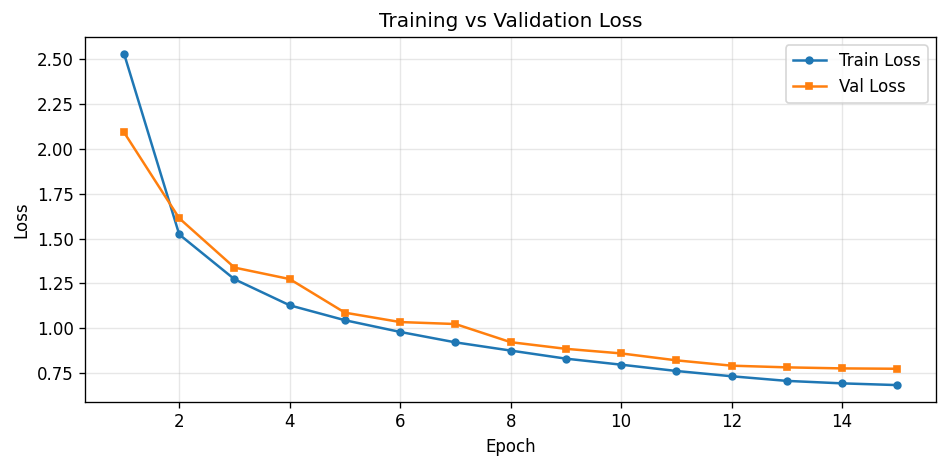

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
epochs_range = range(1, NUM_EPOCHS + 1)
ax.plot(epochs_range, history["train_loss"], "o-", label="Train Loss", markersize=4)
ax.plot(epochs_range, history["val_loss"], "s-", label="Val Loss", markersize=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss")
ax.legend()
plt.tight_layout()
plt.show()

## 4.3 Accuracy Curves

We plot accuracy alongside loss for a more interpretable view.
The gap between train and val accuracy indicates overfitting severity.

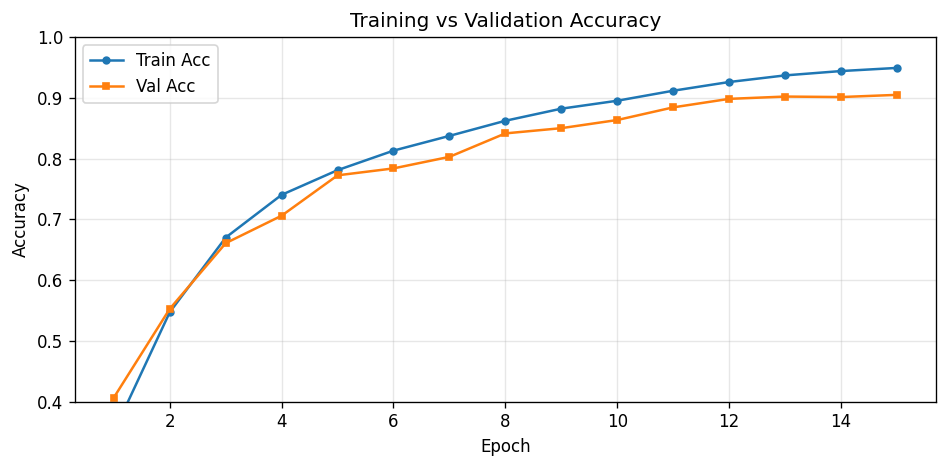

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_range, history["train_acc"], "o-", label="Train Acc", markersize=4)
ax.plot(epochs_range, history["val_acc"], "s-", label="Val Acc", markersize=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Training vs Validation Accuracy")
ax.legend()
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

## 4.4 Learning Rate Schedule Visualization

Verify that the LR schedule behaves as designed: linear warmup for 2 epochs,
then smooth cosine decay. The shape should look like a bell curve's right half.

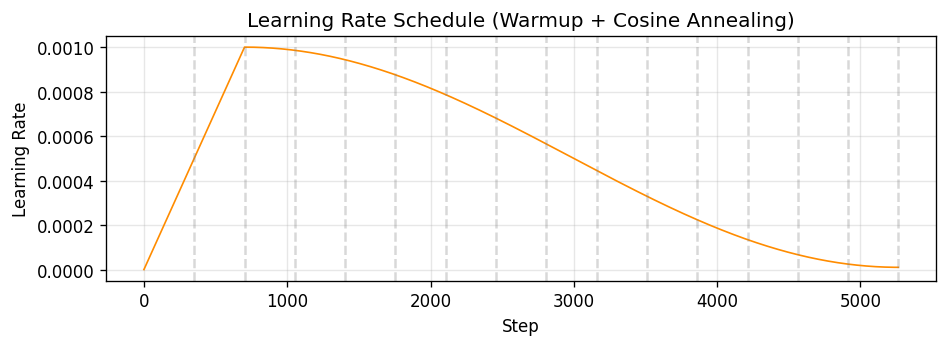

In [22]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(history["lr_values"], linewidth=1.0, color="darkorange")
ax.set_xlabel("Step")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule (Warmup + Cosine Annealing)")

# Mark epoch boundaries
for e in range(1, NUM_EPOCHS + 1):
    ax.axvline(x=e * steps_per_epoch, color="gray", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## 4.5 Gradient Norm Monitoring

Monitoring gradient norms reveals training health (NB03 §3.4):
- **Stable norms** → healthy training.
- **Spikes** → potential instability; clipping is catching them.
- **Vanishing norms** → gradients dying; may need architecture/LR changes.
- **Steady growth** → potential exploding gradients.

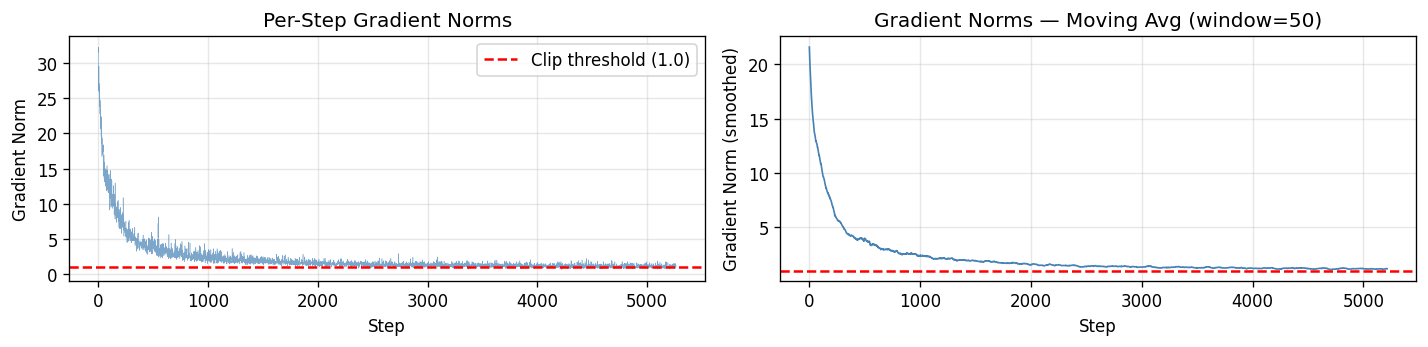

Fraction of steps where clipping was active: 94.3%
Mean gradient norm: 2.262, Max: 32.184


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Raw gradient norms
axes[0].plot(history["grad_norms"], linewidth=0.3, alpha=0.7, color="steelblue")
axes[0].axhline(y=MAX_GRAD_NORM, color="red", linestyle="--", label=f"Clip threshold ({MAX_GRAD_NORM})")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Gradient Norm")
axes[0].set_title("Per-Step Gradient Norms")
axes[0].legend()

# Smoothed (moving average) gradient norms
window = 50
norms = np.array(history["grad_norms"])
if len(norms) > window:
    smoothed = np.convolve(norms, np.ones(window) / window, mode="valid")
    axes[1].plot(smoothed, linewidth=1.0, color="steelblue")
    axes[1].axhline(y=MAX_GRAD_NORM, color="red", linestyle="--")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Gradient Norm (smoothed)")
    axes[1].set_title(f"Gradient Norms — Moving Avg (window={window})")

plt.tight_layout()
plt.show()

clipped_frac = np.mean(norms > MAX_GRAD_NORM)
print(f"Fraction of steps where clipping was active: {clipped_frac:.1%}")
print(f"Mean gradient norm: {norms.mean():.3f}, Max: {norms.max():.3f}")

---
# 5) Evaluation & Error Analysis

Final evaluation is done on the **held-out test set** — data the model has never seen
during training or hyperparameter selection. We go beyond top-line accuracy with
per-class analysis, confusion matrices, and error visualisation.

## 5.1 Test Set Evaluation

In [24]:
test_metrics = evaluate(model, test_loader, criterion, device)
print(f"Test Loss:     {test_metrics['loss']:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.4f} ({test_metrics['accuracy'] * 100:.1f}%)")

Test Loss:     0.7868
Test Accuracy: 0.8967 (89.7%)


## 5.2 Confusion Matrix

The confusion matrix reveals which classes the model confuses. Common CIFAR-10
confusions: cat↔dog, automobile↔truck, deer↔horse.

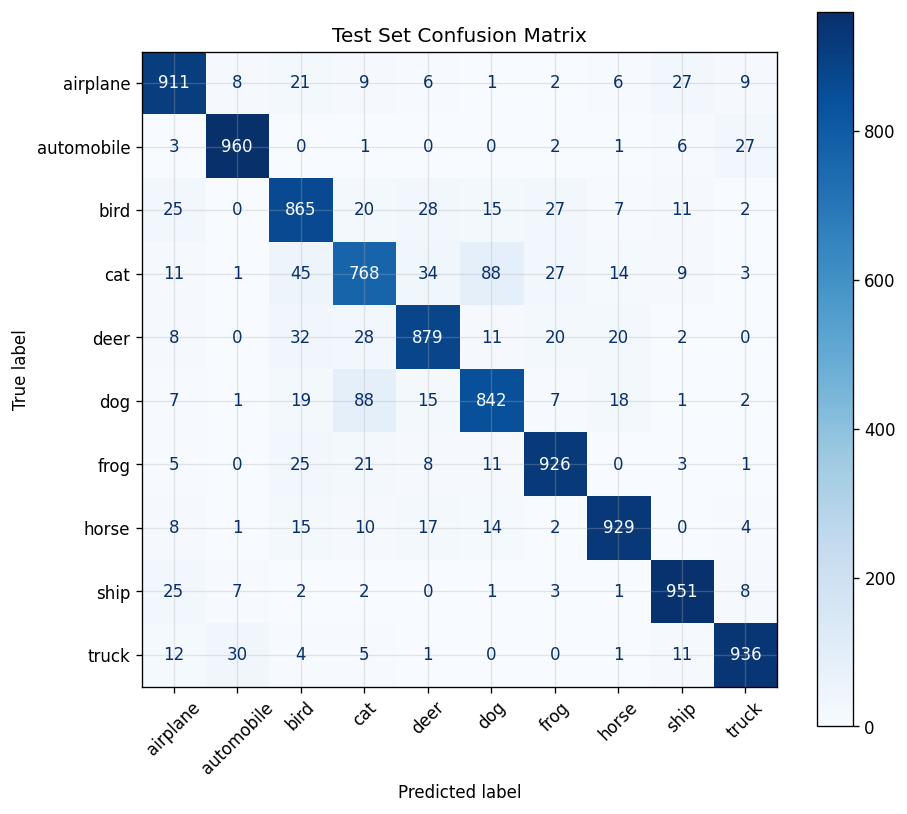

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    test_metrics["labels"].numpy(),
    test_metrics["preds"].numpy(),
    labels=range(num_classes),
)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CIFAR10_CLASSES)
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
ax.set_title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

## 5.3 Per-Class Accuracy

Aggregate accuracy can mask poor performance on specific classes.
Per-class accuracy highlights where the model struggles.

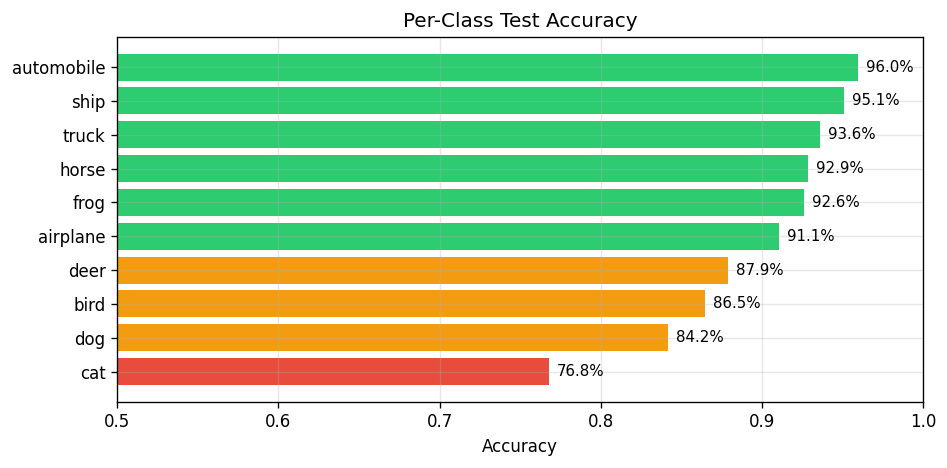

In [26]:
per_class_correct = defaultdict(int)
per_class_total = defaultdict(int)

for pred, label in zip(test_metrics["preds"].tolist(), test_metrics["labels"].tolist()):
    per_class_total[label] += 1
    if pred == label:
        per_class_correct[label] += 1

per_class_acc = {
    CIFAR10_CLASSES[k]: per_class_correct[k] / per_class_total[k]
    for k in range(num_classes)
}

# Sort by accuracy
sorted_acc = sorted(per_class_acc.items(), key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(8, 4))
classes, accs = zip(*sorted_acc)
colours = ["#e74c3c" if a < 0.80 else "#2ecc71" if a > 0.90 else "#f39c12" for a in accs]
ax.barh(classes, accs, color=colours)
ax.set_xlabel("Accuracy")
ax.set_title("Per-Class Test Accuracy")
ax.set_xlim(0.5, 1.0)
for i, (cls, acc) in enumerate(sorted_acc):
    ax.text(acc + 0.005, i, f"{acc:.1%}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 5.4 Visualize Misclassified Examples

Looking at *what* the model gets wrong is more informative than looking at what
it gets right. Common failure modes: ambiguous images, unusual viewpoints,
inter-class similarity (cat vs dog).

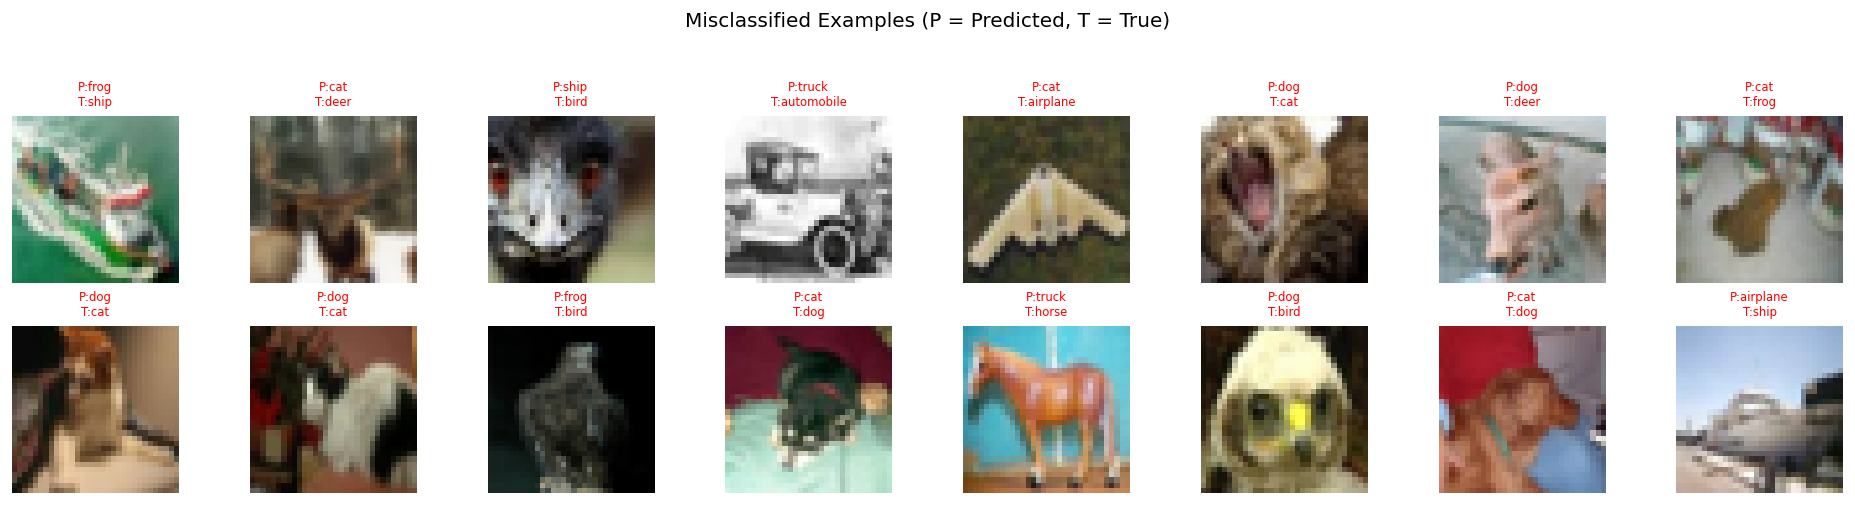

In [27]:
def denormalize(img_tensor, mean, std):
    """Reverse normalization for visualization."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)


# Collect misclassified examples from the test set
misclassified = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        logits = model(images_dev)
        preds = logits.argmax(dim=1).cpu()
        mask = preds != labels
        for img, pred, true in zip(images[mask], preds[mask], labels[mask]):
            misclassified.append((img, pred.item(), true.item()))
        if len(misclassified) >= 20:
            break

# Show 16 misclassified examples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for idx, ax in enumerate(axes.flat):
    if idx >= len(misclassified):
        ax.axis("off")
        continue
    img, pred, true = misclassified[idx]
    img_vis = denormalize(img, CIFAR10_MEAN, CIFAR10_STD).permute(1, 2, 0).numpy()
    ax.imshow(img_vis)
    ax.set_title(f"P:{CIFAR10_CLASSES[pred]}\nT:{CIFAR10_CLASSES[true]}", fontsize=7, color="red")
    ax.axis("off")
fig.suptitle("Misclassified Examples (P = Predicted, T = True)", fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

## 5.5 What the Network Learned — First-Layer Filter Visualization

The first convolutional layer learns basic feature detectors: edges, colour blobs,
and simple textures. Visualizing these filters confirms the network is learning
meaningful representations rather than noise.

For deeper layers, we show a simplified *gradient-weighted class activation map*
(Grad-CAM) that highlights which spatial regions the network focuses on.

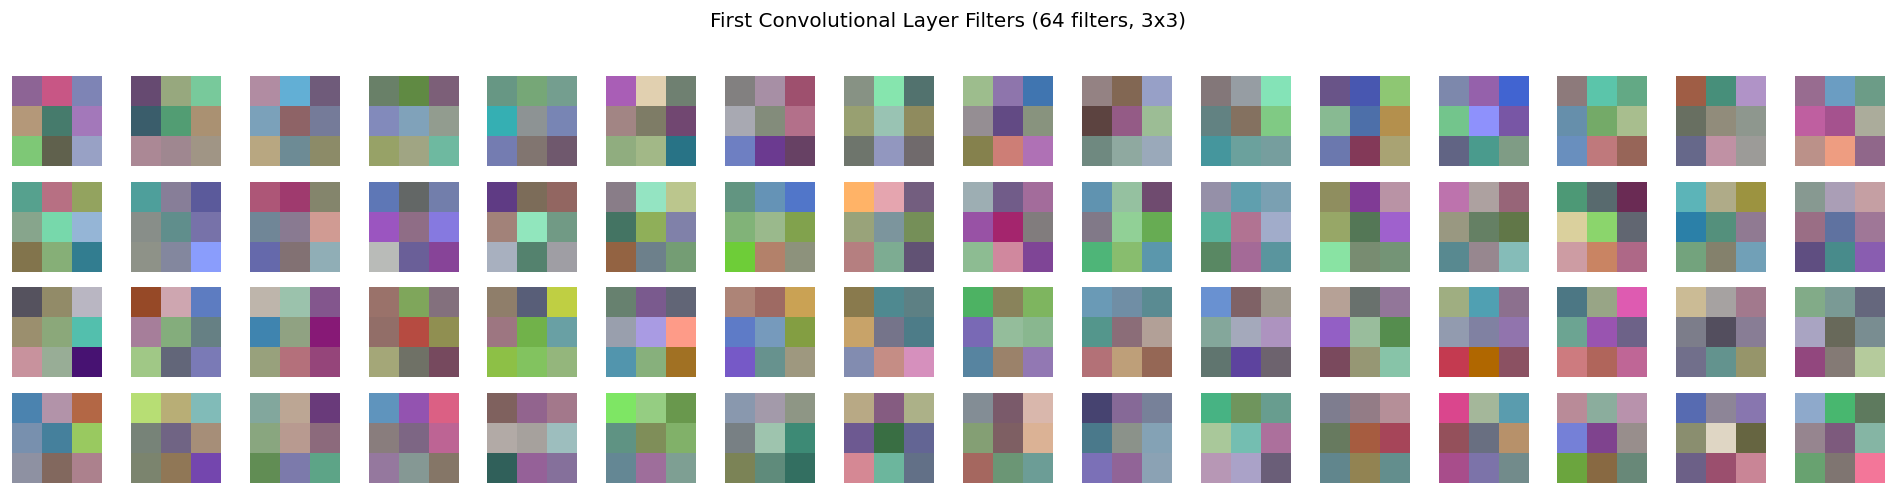

In [28]:
# Visualize first-layer filters (stem conv)
first_conv = model.stem[0]
filters = first_conv.weight.data.cpu().clone()
# (64, 3, 3, 3) -> normalize each filter to [0, 1] for display
filters = filters - filters.min()
filters = filters / (filters.max() + 1e-8)

fig, axes = plt.subplots(4, 16, figsize=(16, 4))
for idx, ax in enumerate(axes.flat):
    if idx < filters.shape[0]:
        # (3, 3, 3) -> transpose for imshow
        ax.imshow(filters[idx].permute(1, 2, 0).numpy())
    ax.axis("off")
fig.suptitle("First Convolutional Layer Filters (64 filters, 3x3)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

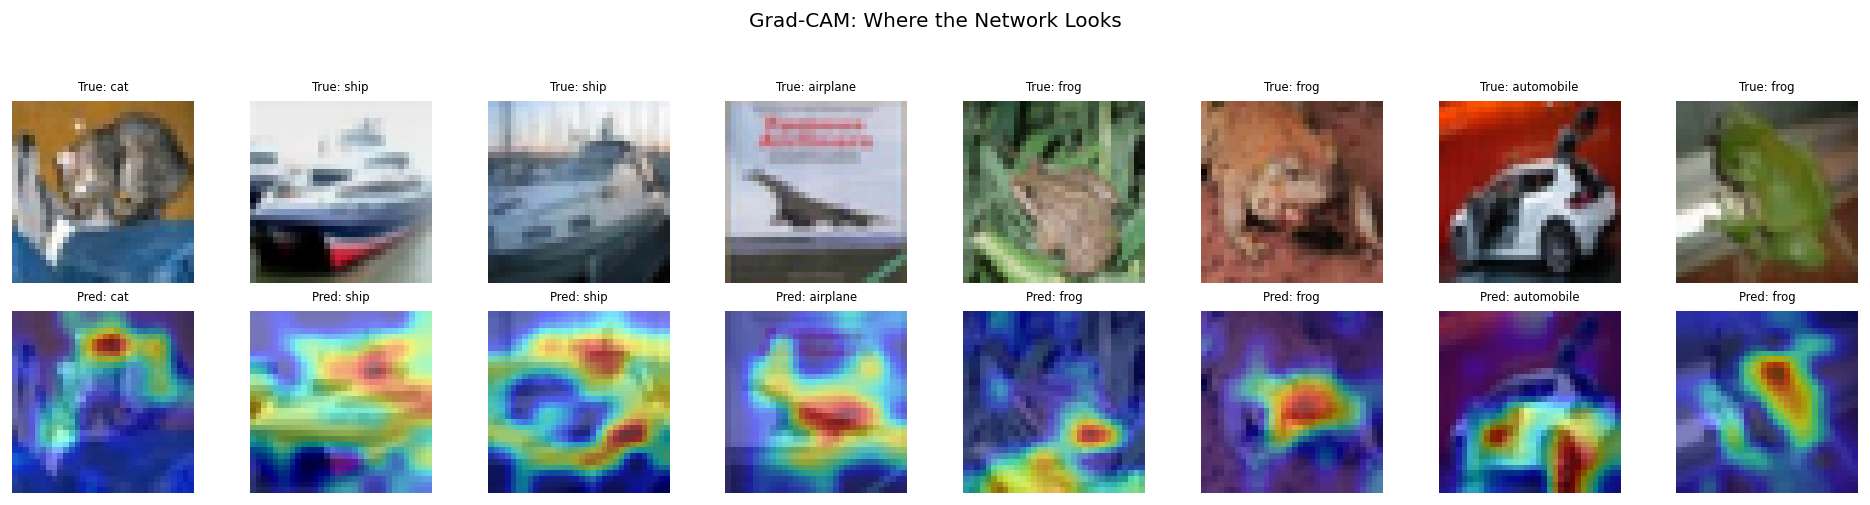

In [29]:
import matplotlib.cm as cm_module
from PIL import Image as PILImage


def simple_grad_cam(model, image, target_class=None):
    """Compute a basic Grad-CAM heatmap for the last conv stage."""
    model.eval()

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.stage3.register_forward_hook(forward_hook)
    handle_bwd = model.stage3.register_full_backward_hook(backward_hook)

    # (1, 3, 32, 32) -> (1, num_classes)
    logits = model(image.unsqueeze(0).to(device))

    if target_class is None:
        target_class = logits.argmax(dim=1).item()

    model.zero_grad()
    logits[0, target_class].backward()

    # Global-average-pool gradients as channel weights
    # (1, 256, 8, 8) -> (256,)
    weights = gradients["value"].mean(dim=(2, 3)).squeeze(0)
    # Weighted sum of activations: (256, 8, 8) -> (8, 8)
    activation_map = (weights.unsqueeze(-1).unsqueeze(-1) * activations["value"].squeeze(0)).sum(dim=0)
    activation_map = F.relu(activation_map)
    activation_map = activation_map - activation_map.min()
    activation_map = activation_map / (activation_map.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return activation_map.detach().cpu().numpy(), target_class


# Grad-CAM for 8 test images
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
sample_images, sample_labels = next(iter(test_loader))

for idx in range(8):
    img = sample_images[idx]
    true_label = sample_labels[idx].item()

    activation_map, pred_class = simple_grad_cam(model, img)
    img_vis = denormalize(img, CIFAR10_MEAN, CIFAR10_STD).permute(1, 2, 0).numpy()

    axes[0, idx].imshow(img_vis)
    axes[0, idx].set_title(f"True: {CIFAR10_CLASSES[true_label]}", fontsize=7)
    axes[0, idx].axis("off")

    # Resize CAM and create overlay
    cam_resized = np.array(
        PILImage.fromarray((activation_map * 255).astype(np.uint8)).resize((32, 32))
    ) / 255.0
    heatmap = cm_module.jet(cam_resized)[:, :, :3]
    overlay = 0.5 * img_vis + 0.5 * heatmap

    axes[1, idx].imshow(overlay)
    axes[1, idx].set_title(f"Pred: {CIFAR10_CLASSES[pred_class]}", fontsize=7)
    axes[1, idx].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=9)
axes[1, 0].set_ylabel("Grad-CAM", fontsize=9)
fig.suptitle("Grad-CAM: Where the Network Looks", fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

## 5.6 Common Pitfalls & How to Diagnose Them

| Symptom | Likely Cause | Diagnosis | Fix |
|---|---|---|---|
| Loss = NaN after few steps | Exploding gradients or bad LR | Check grad norms, check LR | Lower LR, add grad clipping, check data for NaN |
| Loss stuck at ln(K) | Model outputting uniform distribution | Print logits — are they all ~0? | Check init, check if gradients flow (add hooks) |
| Train acc 100%, val acc 60% | Severe overfitting | Gap in loss/acc curves | Add regularisation (NB03): dropout, weight decay, augmentation, reduce model size |
| Train acc plateaus at 50% | Underfitting | Both train & val acc low | Increase model capacity, lower regularisation, increase LR |
| Val loss increases, train loss decreases | Overfitting onset | Diverging curves | Early stopping, stronger regularisation |
| Training unstable (loss oscillates) | LR too high | Loss curve is spiky | Lower LR, add warmup |
| Very slow convergence | LR too low or bad normalisation | Loss decreases at glacial pace | Increase LR, check normalisation, check init |
| Different results every run | Non-determinism | Set all seeds, check CUDNN | `torch.backends.cudnn.deterministic = True` |

### The Most Important Lesson

> **Ablation studies are your best friend.** When something works (or doesn't), change
> *one thing at a time* and measure the effect. This is how you build real understanding,
> and it's what separates good papers from great ones.

---
# Summary

**Key takeaways:**
1. Every component choice has a *reason*. Never use a technique without understanding *why*.
2. Monitor everything: loss, accuracy, gradient norms, LR, per-class metrics.
3. Debug systematically: single-batch overfit → data checks → gradient checks → optimisation.
4. Ablation studies are how you build understanding and write good papers.

**Next steps for the ambitious PhD student:**
- Try replacing ReLU with GELU or SiLU and measure the effect.
- Implement CutMix or MixUp augmentation.
- Add dropout and compare with/without weight decay.
- Scale up to CIFAR-100 (100 classes, same images) — what changes?
- Implement a full hyperparameter sweep using Optuna.
- Try a Vision Transformer (ViT) on the same data and compare.